<a href="https://colab.research.google.com/github/omarpb03/Data-Science-ML-Fundamentals-Python/blob/main/housing_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Vamos a trabajar con el dataset California Housing Prices

In [ ]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
    with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing = load_housing_data()

/tmp/ipykernel_4070/2839428726.py:13: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tarball.extractall(path="datasets")


In [ ]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## Meta: El modelo deberia aprender a predecir la mediana del precio de por hogar en cualquier distrito.

En este caso es un problema de aprendizaje supervisado, de regresion multiple, y hay que usar batch.

In [ ]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


Observamos que la variable total_bedrooms tiene algunos valores nulos (207). Y casi todos los atributos son de tipo flotante, a excepcion de ocean_proximity, probablemente sea una variable categorica. Usando el metodo value_counts() veamos cuantas y que categorias tiene:

In [ ]:
housing["ocean_proximity"]

0        NEAR BAY
1        NEAR BAY
2        NEAR BAY
3        NEAR BAY
4        NEAR BAY
           ...   
20635      INLAND
20636      INLAND
20637      INLAND
20638      INLAND
20639      INLAND
Name: ocean_proximity, Length: 20640, dtype: object

In [ ]:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

Veamos los otros atributos. El metodo describe() nos da un resumen de los atributos numericos:

In [ ]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [ ]:
# extra code – code to save the figures as high-res PNGs for the book

IMAGES_PATH = Path() / "images" / "end_to_end_project"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

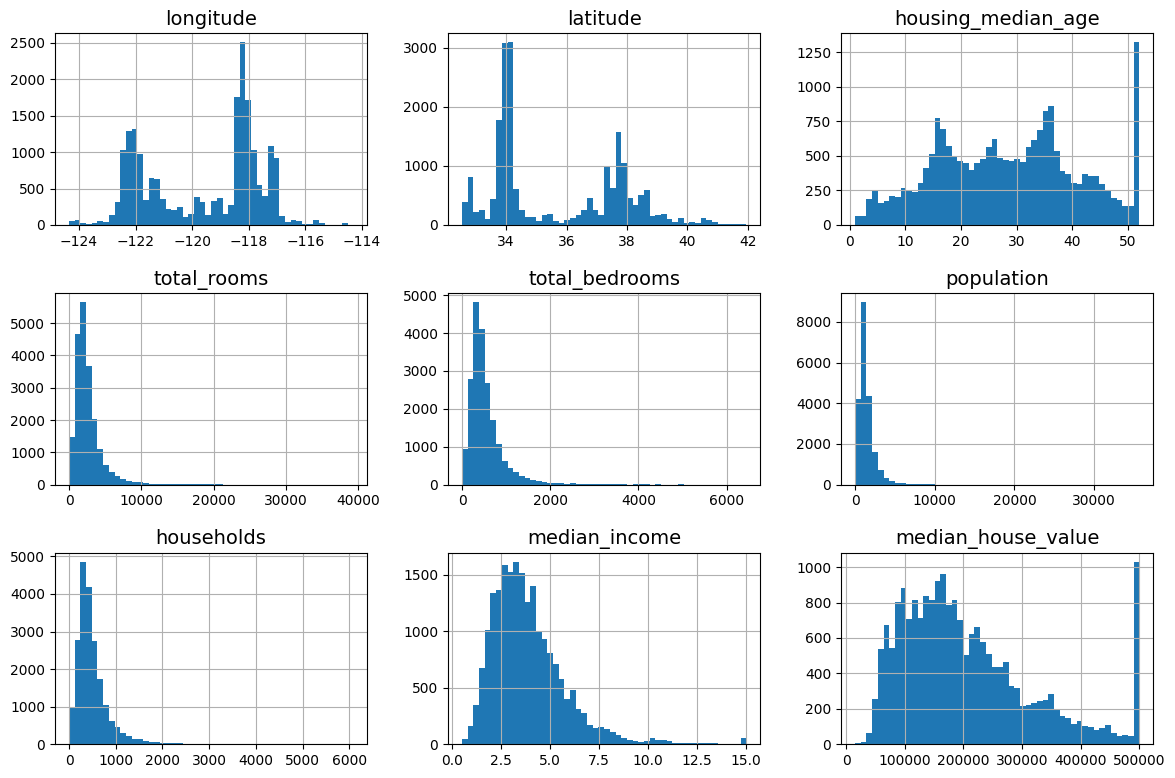

In [ ]:
import matplotlib.pyplot as plt

# extra code – the next 5 lines define the default font sizes
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

housing.hist(bins=50, figsize=(12, 8))
save_fig("attribute_histogram_plots")  # extra code
plt.show()

Aqui hay que notar algunas cosas:
- Parece ser que la variable median_income no esta expresada en USD, sino en decenas de miles de USD (por ejemplo, 3 en realidad significa $30,000). Esto es porque los datos fueron escalados y limitados a 15 (en realidad a 15.0001) para valores altos de ingresos y a 0.5 (0.4999) para valores bajos.
- Tambien las variables housing_median_age y median_house_value estan limitados, y este ultimo podria implicar un problema ya que es nuestra variable objetivo. El algoritmo podria aprender que los precios no deberian pasar de ese limite.
- Estos atributos tienen escalas muy diferentes.
- Por ultimo, muchos histogramas estan sesgados a la derecha.

## Creamos un conjunto de prueba
Creamos un conjunto de observaciones elegidas de manera aleatoria ( aprox. el 20% de nuestros datos ) y los separamos de la muestra original.

In [ ]:
import numpy as np
#Esta funcion es una version "manual" de la funcion train_test_split de Scikit-Learn
def shuffle_and_split_data(data, test_ratio):
    shuffled_indices = np.random.permutation(len(data))#creamos una lista de indices aleatorios
    test_set_size = int(len(data) * test_ratio)#calcula cuantas filas iran al conjunto de prueba
    test_indices = shuffled_indices[:test_set_size]#toma los primeros indices ( de acuerdo al test_ratio ) para el test_set
    train_indices = shuffled_indices[test_set_size:]#toma el resto de los indices para el training_set
    return data.iloc[train_indices], data.iloc[test_indices]#extrae las filas de la tabla usando los indices seleccionados. Esto crea 2 dataframes

In [ ]:
train_set, test_set = shuffle_and_split_data(housing, 0.2)
len(train_set)

16512

In [ ]:
len(test_set)

4128

Antes de seguir checando los datos hay que crear un grupo de entrenamiento y uno de prueba.
Un detalle importante es que si volvemos a correr el programa, nos generara un conjunto de prueba distinto, es decir, conforme pase el tiempo, el algoritmo terminara viendo el conjunto de datos completo, que es algo que queremos evitar.
Una forma de evitar esta situacion es fijar una semilla generadora de numeros aleatorios antes de  np.random.permutation(), para que siempre genere los mismos indices mezclados.

In [ ]:
np.random.seed(42)#42 por convencion

In [ ]:
from zlib import crc32#la funcion crc32 convierte el ID en un numero hash unico

def is_id_in_test_set(identifier, test_ratio):
    return crc32(np.int64(identifier)) < test_ratio * 2**32# se genera un numero entero basandose en el ID, y si el numero hash es menor que el umbral
    #(test_ratio * 2**32), entonces la fila se va al conjunto de prueba.

def split_data_with_id_hash(data, test_ratio, id_column):
    ids = data[id_column]
    in_test_set = ids.apply(lambda id_: is_id_in_test_set(id_, test_ratio))
    return data.loc[~in_test_set], data.loc[in_test_set]

In [ ]:
housing_with_id = housing.reset_index()  # agrega una columna indicadora como identificador unico
train_set, test_set = split_data_with_id_hash(housing_with_id, 0.2, "index")

Al usar una columna como identificador unico, debemos asegurarnos de que los nuevos datos se agreguen al final del conjunto de datos y de que ninguna fila se borre.

Tambien podemos usar las variables mas estables para armar un identificador unico. Por ejemplo, la latitud y la longitud de un distrito nunca cambiaran.

In [ ]:
housing_with_id["id"] = housing["longitude"] * 1000 + housing["latitude"]
train_set, test_set = split_data_with_id_hash(housing_with_id, 0.2, "id")

In [ ]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

In [ ]:
test_set["total_bedrooms"].isnull().sum()

In [ ]:
housing["income_cat"] = pd.cut(housing["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])

In [ ]:
housing["income_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.xlabel("Income category")
plt.ylabel("Number of districts")
save_fig("housing_income_cat_bar_plot")  # extra code
plt.show()

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit

splitter = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
strat_splits = []
for train_index, test_index in splitter.split(housing, housing["income_cat"]):
    strat_train_set_n = housing.iloc[train_index]
    strat_test_set_n = housing.iloc[test_index]
    strat_splits.append([strat_train_set_n, strat_test_set_n])

In [ ]:
strat_train_set, strat_test_set = strat_splits[0]

In [ ]:
strat_train_set, strat_test_set = train_test_split(
    housing, test_size=0.2, stratify=housing["income_cat"], random_state=42)

In [ ]:
strat_test_set["income_cat"].value_counts() / len(strat_test_set)

In [ ]:
# extra code – computes the data for Figure 2–10

def income_cat_proportions(data):
    return data["income_cat"].value_counts() / len(data)

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

compare_props = pd.DataFrame({
    "Overall %": income_cat_proportions(housing),
    "Stratified %": income_cat_proportions(strat_test_set),
    "Random %": income_cat_proportions(test_set),
}).sort_index()
compare_props.index.name = "Income Category"
compare_props["Strat. Error %"] = (compare_props["Stratified %"] /
                                   compare_props["Overall %"] - 1)
compare_props["Rand. Error %"] = (compare_props["Random %"] /
                                  compare_props["Overall %"] - 1)
(compare_props * 100).round(2)

In [ ]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

In [ ]:
housing = strat_train_set.copy() #Since you’re going to experiment with various transformations of the full training set, you
 #should make a copy of the original so you can revert to it afterwards

## Visualizing Geographical Data

In [ ]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True)
save_fig("bad_visualization_plot")  # extra code
plt.show()

In [ ]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True, alpha=0.2)
save_fig("better_visualization_plot")  # extra code
plt.show() # Setting the alpha option to 0.2 makes it much easier to visualize the places where there is a high density of data points

In [ ]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True,
             s=housing["population"] / 100, label="population",
             c="median_house_value", cmap="jet", colorbar=True,
             legend=True, sharex=False, figsize=(10, 7))
save_fig("housing_prices_scatterplot")  # extra code
plt.show()

In [ ]:
# extra code – this cell generates the first figure in the chapter

# Download the California image
filename = "california.png"
if not (IMAGES_PATH / filename).is_file():
    homl3_root = "https://github.com/ageron/handson-ml3/raw/main/"
    url = homl3_root + "images/end_to_end_project/" + filename
    print("Downloading", filename)
    urllib.request.urlretrieve(url, IMAGES_PATH / filename)

housing_renamed = housing.rename(columns={
    "latitude": "Latitude", "longitude": "Longitude",
    "population": "Population",
    "median_house_value": "Median house value (ᴜsᴅ)"})
housing_renamed.plot(
             kind="scatter", x="Longitude", y="Latitude",
             s=housing_renamed["Population"] / 100, label="Population",
             c="Median house value (ᴜsᴅ)", cmap="jet", colorbar=True,
             legend=True, sharex=False, figsize=(10, 7))

california_img = plt.imread(IMAGES_PATH / filename)
axis = -124.55, -113.95, 32.45, 42.05
plt.axis(axis)
plt.imshow(california_img, extent=axis)

save_fig("california_housing_prices_plot")
plt.show()

## Looking for Correlations

In [ ]:
corr_matrix = housing.corr(numeric_only=True) # the numeric_only argument defaults to False, so we need to set it explicitly to True to avoid an error.

In [ ]:
corr_matrix["median_house_value"].sort_values(ascending=False)

In [ ]:
from pandas.plotting import scatter_matrix
#vamos a elegir solo unos cuantos atributos que son los que mayor correlacion parecen tener con la variable objetivo

attributes = ["median_house_value", "median_income", "total_rooms",
              "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12, 8))
save_fig("scatter_matrix_plot")  # extra code
plt.show()

In [ ]:
housing.plot(kind="scatter", x="median_income", y="median_house_value",
             alpha=0.1, grid=True)
save_fig("income_vs_house_value_scatterplot")  # extra code
plt.show() # it seems like the most promising attribute
 #to predict the median house value is the median income, so you zoom in on their
 #scatterplot

In [ ]:
 housing["rooms_per_house"] = housing["total_rooms"] / housing["households"]
 housing["bedrooms_ratio"] = housing["total_bedrooms"] / housing["total_rooms"]
 housing["people_per_house"] = housing["population"] / housing["households"]

In [ ]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

Ahora vamos a preparar los datos . Es recomendable separar las variables predictoras y las variables explicatorias, pues no necesariamente
se les aplican las mismas transformaciones a ambos.


In [ ]:
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

In [ ]:
null_rows_idx = housing.isnull().any(axis=1)
housing.loc[null_rows_idx].head()

In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

In [ ]:
housing_num = housing.select_dtypes(include=[np.number])

In [ ]:
imputer.fit(housing_num)

In [ ]:
imputer.statistics_

verificamos que da los mismos valores

In [ ]:
housing_num.median().values

Ahora, podemos usar este imputer "entrenado" para transormar el conjunto de entrenamiento reeplazando los missings con las medianas

In [ ]:
X = imputer.transform(housing_num)

In [ ]:
imputer.feature_names_in_

In [ ]:
housing_tr = pd.DataFrame(X, columns=housing_num.columns,
                          index=housing_num.index)

In [ ]:
housing_tr.loc[null_rows_idx].head()
#selecciona todas las filas que tienen al menos un valor nulo (faltante) y luego muestra las primeras 5 de esas filas.

In [ ]:
imputer.strategy

La linea de arriba muestra qué método o técnica se está usando para rellenar los valores faltantes

En este caso, es la mediana.


In [ ]:
#Este código primero crea y luego entrena un modelo que aprende cómo es la "normalidad" en tus datos.
#Después, lo utiliza para etiquetar cada punto de dato como normal (1) o como un outlier (-1).
from sklearn.ensemble import IsolationForest

isolation_forest = IsolationForest(random_state=42) #42 por convencion
outlier_pred = isolation_forest.fit_predict(X) #el modelo clasifica cada punto de dato en X y devuelve una predicción.

In [ ]:
outlier_pred

In [ ]:
#Para retirar los outliers usariamos:
#housing = housing.iloc[outlier_pred == 1]
#housing_labels = housing_labels.iloc[outlier_pred == 1]

# Ahora vamos a echar un vistazo a la variable ocean_proximity cuyos atributos son de tipo texto

In [ ]:
housing_cat = housing[["ocean_proximity"]]
housing_cat.head(8)

Como hay una cantidad finita de posibles valores, cada uno representa una categoria, por lo que es un artibuto categorico.
Entonces, vamos a convertirlos a valores numericos.

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)

In [ ]:
housing_cat_encoded[:8]

In [ ]:
ordinal_encoder.categories_ #es una lista que contiene un arreglo de categorias para cada atributo categorico.

In [ ]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

housing_cat_1hot almacena el resultado final: una matriz numérica (generalmente una matriz dispersa o sparse matrix para ahorrar memoria) que representa tus datos categóricos originales.

In [ ]:
housing_cat_1hot


Una matriz dispersa (sparse matrix) es una representación muy eficiente para matrices que contienen mayoritariamente ceros. De hecho, internamente solo almacena los valores no nulos y sus posiciones.

Cuando un atributo categórico tiene cientos o miles de categorías, al aplicarle la codificación one-hot se obtiene una matriz muy grande llena de ceros, a excepción de un único 1 por fila. En este caso, una matriz dispersa es exactamente lo que necesitas: ahorrará muchísima memoria y acelerará los cómputos.

Tambien podemos convertirlo a un arreglo denso:

In [ ]:
housing_cat_1hot.toarray()

Tambien se puede configurar sparse=False cuando creemos el OneHotEncoder:

In [ ]:
cat_encoder = OneHotEncoder(sparse_output=False)
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
housing_cat_1hot

In [ ]:
df_test = pd.DataFrame({"ocean_proximity": ["INLAND", "NEAR BAY"]})
pd.get_dummies(df_test)

Pandas tambien tiene una funcion para convertir una funcion dummy para cada categoria llamada get_dummies()

La ventaja de OneHotEncoder es que recuerda cada categoria en la que se ha entrenado.

In [ ]:
cat_encoder.transform(df_test)

get_dummies() solo vio 2 categorias, por lo que solo mostro dos filas, mientras que OneHotEncoder regreso 1 columna por categoria, en el orden correcto.

In [ ]:
df_test_unknown = pd.DataFrame({"ocean_proximity": ["<2H OCEAN", "ISLAND"]})
pd.get_dummies(df_test_unknown)

In [ ]:
cat_encoder.handle_unknown = "ignore"
cat_encoder.transform(df_test_unknown)

In [ ]:
cat_encoder.feature_names_in_

In [ ]:
cat_encoder.get_feature_names_out()# te devuelve los nombres de estas nuevas columnas generadas.

In [ ]:
df_output = pd.DataFrame(cat_encoder.transform(df_test_unknown), #toma el df original, utiliza el codificador cat_encoder para convertir las columnas
                         #categoricas en formato numerico
                         columns=cat_encoder.get_feature_names_out(),#usamos este argumento para asignar los nombres correctos a cada nueva columna generada
                         index=df_test_unknown.index)#toma el índice (los nombres o números de las filas) del DataFrame original y se lo asigna al nuevo DataFrame

In [ ]:
df_output


## Escalado y Transformación de Características
Una de las transformaciones más importantes que necesitas aplicar a tus datos es el escalado de características. Salvo algunas excepciones, los algoritmos de aprendizaje automático no funcionan bien cuando los atributos numéricos de entrada tienen escalas muy diferentes.

Este es el caso de los datos de vivienda: el número total de habitaciones varía aproximadamente de 6 a 39,320, mientras que los ingresos medianos solo varían de 0 a 15. Sin ningún escalado, la mayoría de los modelos tenderán a ignorar el ingreso mediano y a centrarse más en el número de habitaciones.

Hay dos formas comunes de conseguir que todos los atributos tengan la misma escala: el escalado mínimo-máximo (min-max scaling) y la estandarización (standardization).


El escalado mínimo-máximo (que mucha gente llama normalización) es el más sencillo: para cada atributo, los valores se desplazan y se reescalan de forma que terminan en un rango de 0 a 1.

Esto se realiza restando el valor mínimo y dividiendo por la diferencia entre el valor máximo y el mínimo.

$$X_{escalado}=\frac{X-X_{min}}{X_{max}-X_{min}}$$

In [ ]:
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler(feature_range=(-1, 1))
housing_num_min_max_scaled = min_max_scaler.fit_transform(housing_num)

La estandarización es diferente: primero resta el valor medio (la media), de modo que los valores estandarizados tienen una media de cero. Luego, divide el resultado por la desviación estándar, de modo que los valores estandarizados tienen una desviación estándar igual a 1.

A diferencia del escalado mínimo-máximo, la estandarización no limita los valores a un rango específico. Sin embargo, la estandarización se ve mucho menos afectada por los valores atípicos (outliers).

$$Z=\frac{X-\mu}{\sigma}$$

In [ ]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
housing_num_std_scaled = std_scaler.fit_transform(housing_num)